# Customer Segmentation and Campaign Response Analysis

## Objective
The objective of this project is to analyze customer purchasing behavior and identify meaningful customer segments using unsupervised learning techniques. The analysis includes data cleaning, exploratory data analysis (EDA), outlier detection, hierarchical clustering, and PCA-based visualization. Additionally, a machine learning model is developed to predict customer campaign response based on demographic and purchasing features.

## Author : Mir Musaib

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

In [2]:
import pandas as pd

file_id = "1joZz63r6QLW26ekcttdFHlL8SmxEtrBw"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url, sep="\t", engine="python")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [9]:
df["Age"] = 2025 - df["Year_Birth"]

In [10]:
df[["Age","Income"]].head()

,Age,Income
0,68,58138.0
1,71,46344.0
2,60,71613.0
3,41,26646.0
4,44,58293.0


In [11]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

In [12]:
df["Dt_Customer"].head()

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]

In [13]:
df["Customer_Years"] = 2025 - df["Dt_Customer"].dt.year
df[["Dt_Customer","Customer_Years"]].head()

,Dt_Customer,Customer_Years
0,2012-09-04,13
1,2014-03-08,11
2,2013-08-21,12
3,2014-02-10,11
4,2014-01-19,11


In [14]:
df.dtypes

ID                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
Z_CostContac

In [15]:
df.drop(["Z_CostContact","Z_Revenue"], axis=1, inplace=True)

In [16]:
le = LabelEncoder()

df["Education"] = le.fit_transform(df["Education"])
df["Marital_Status"] = le.fit_transform(df["Marital_Status"])

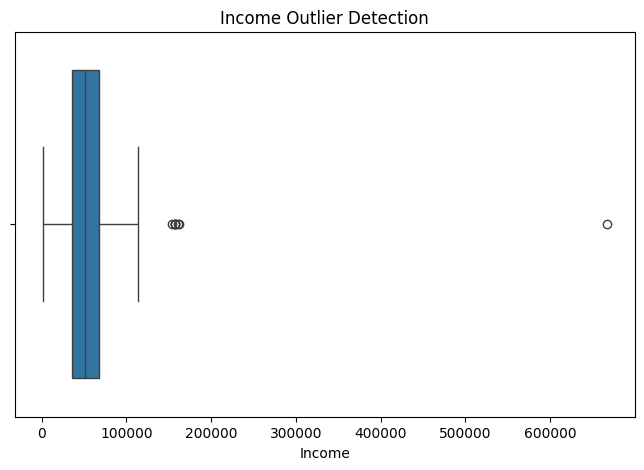

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Income"])

plt.title("Income Outlier Detection")

plt.show()

In [18]:
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Income"] >= lower) & (df["Income"] <= upper)]


In [19]:
df.shape

(2232, 29)

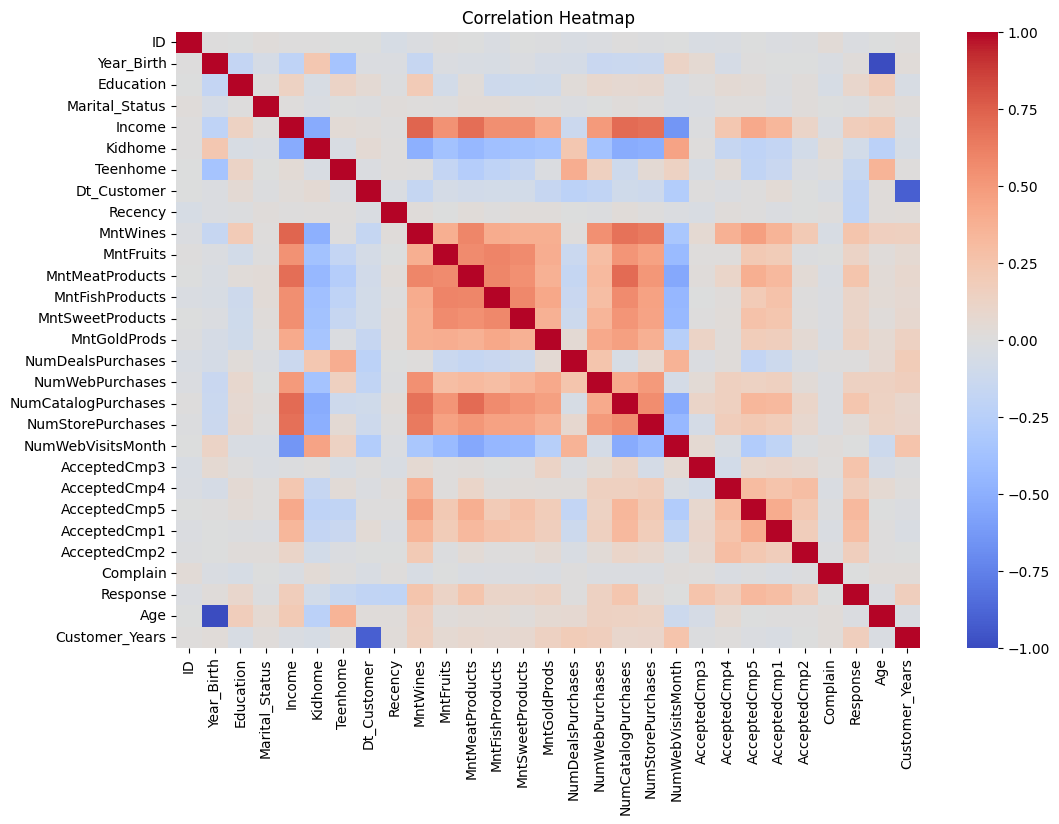

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

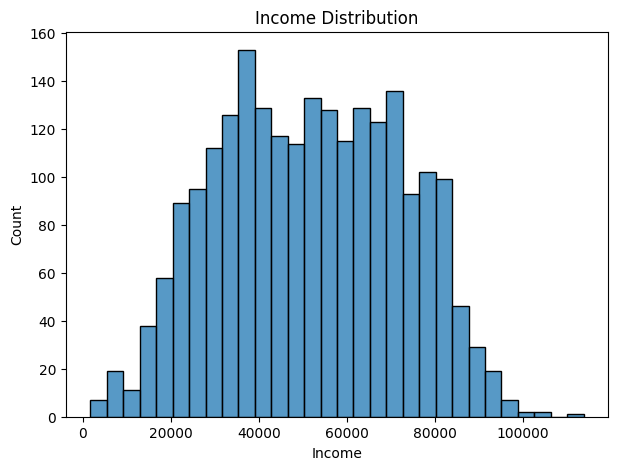

In [21]:
plt.figure(figsize=(7,5))

sns.histplot(df["Income"], bins=30)

plt.title("Income Distribution")

plt.show()

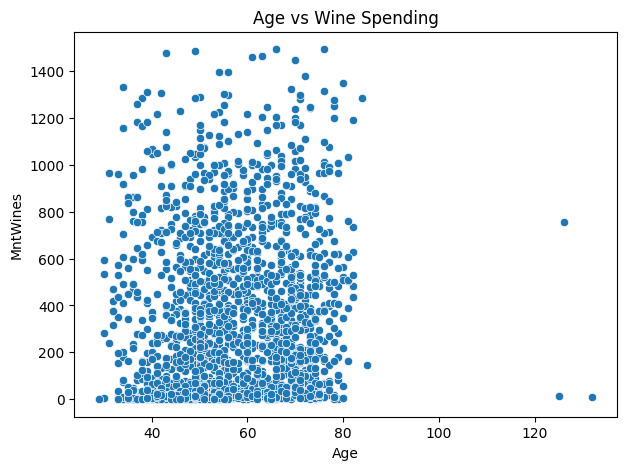

In [22]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Age"],
    y=df["MntWines"]
)

plt.title("Age vs Wine Spending")

plt.show()

In [23]:
df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)
df[["Total_Spending"]].head()

,Total_Spending
0,1617
1,27
2,776
3,53
4,422


In [24]:
X = df[["Income","Total_Spending","Recency","Age"]]

In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

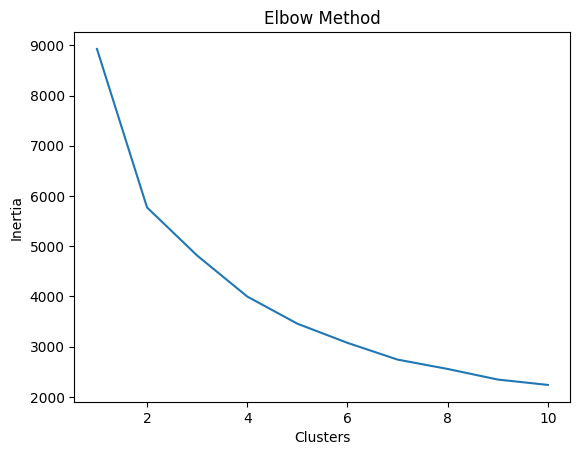

In [26]:
inertia = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia)

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [27]:
kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

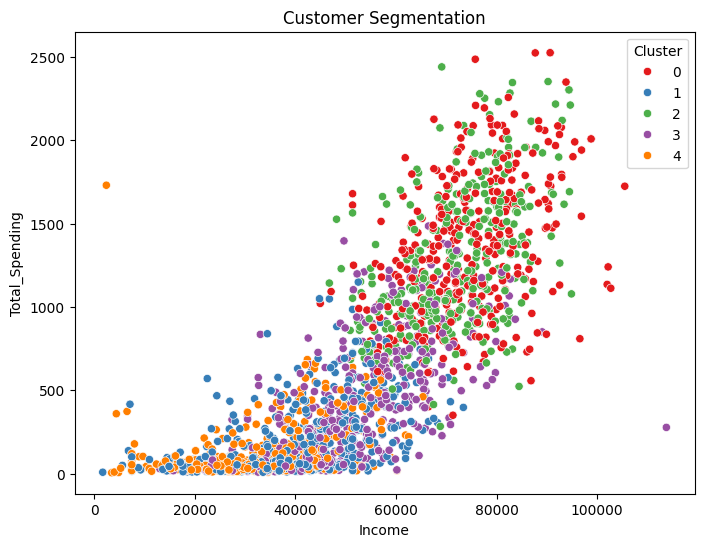

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Income"],
    y=df["Total_Spending"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Customer Segmentation")

plt.show()

In [29]:
df.groupby("Cluster")[["Income","Total_Spending","Age"]].mean()

,Income,Total_Spending,Age
Cluster,,,
0,74114.803665,1344.900524,48.138743
1,39266.698427,198.629371,54.756993
2,71958.119891,1268.335150,65.929155
3,53193.017943,472.169856,67.382775
4,32098.399594,124.699797,47.430020


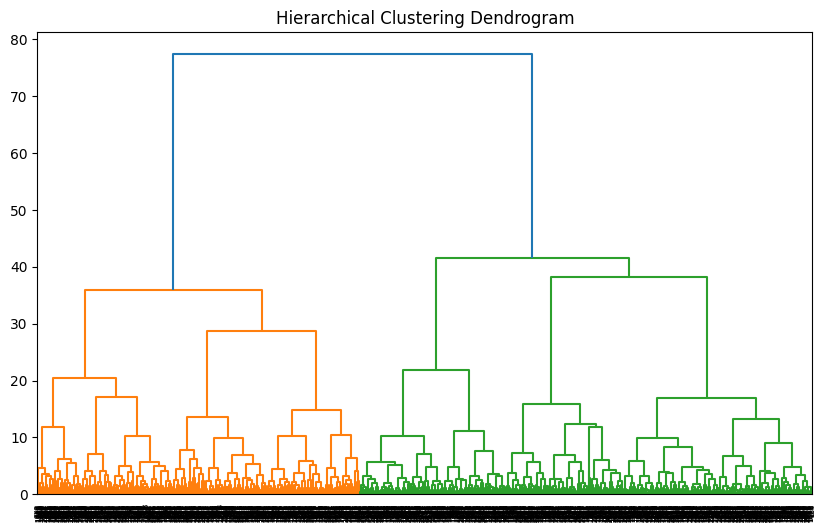

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [31]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)

df["HC_Cluster"] = hc.fit_predict(X_scaled)

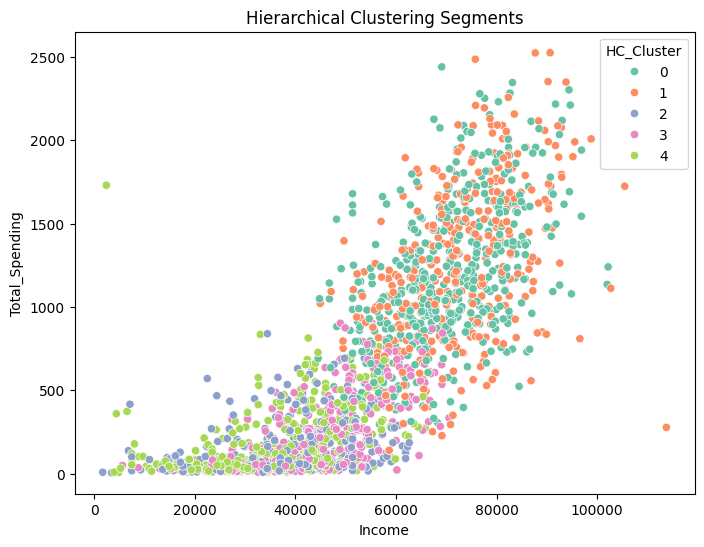

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Income"],
    y=df["Total_Spending"],
    hue=df["HC_Cluster"],
    palette="Set2"
)

plt.title("Hierarchical Clustering Segments")

plt.show()

In [33]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])

pca_df["Cluster"] = df["HC_Cluster"]

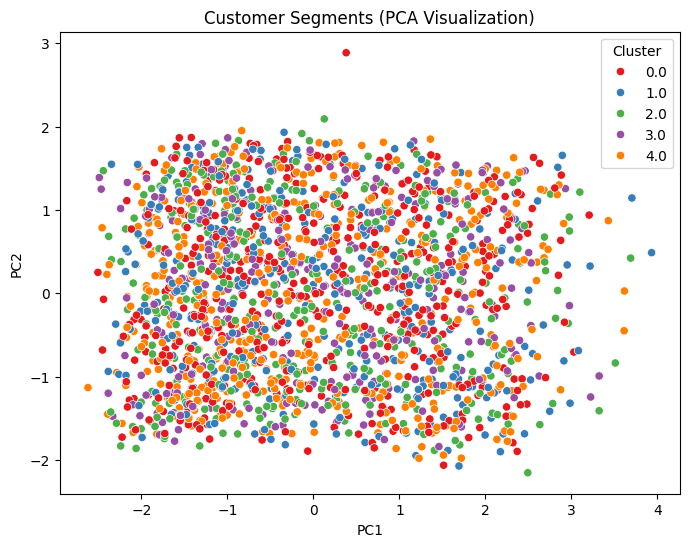

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["Cluster"],
    palette="Set1"
)

plt.title("Customer Segments (PCA Visualization)")

plt.show()

In [35]:
X = df.drop(columns=["Response","Dt_Customer"])
y = df["Response"]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
features = ["Income","Recency","Age","Total_Spending"]

X = df[features]
y = df["Response"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8501118568232662
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       378
           1       0.54      0.22      0.31        69

    accuracy                           0.85       447
   macro avg       0.70      0.59      0.61       447
weighted avg       0.82      0.85      0.82       447



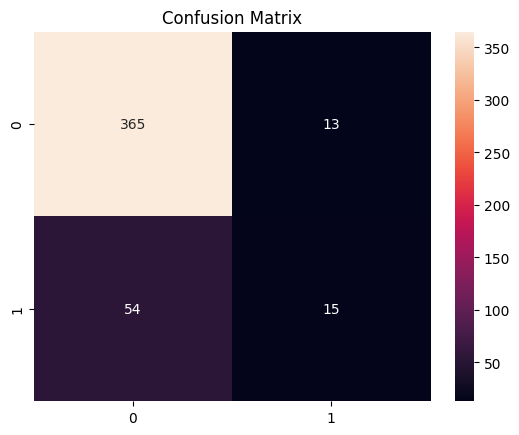

In [40]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.show()

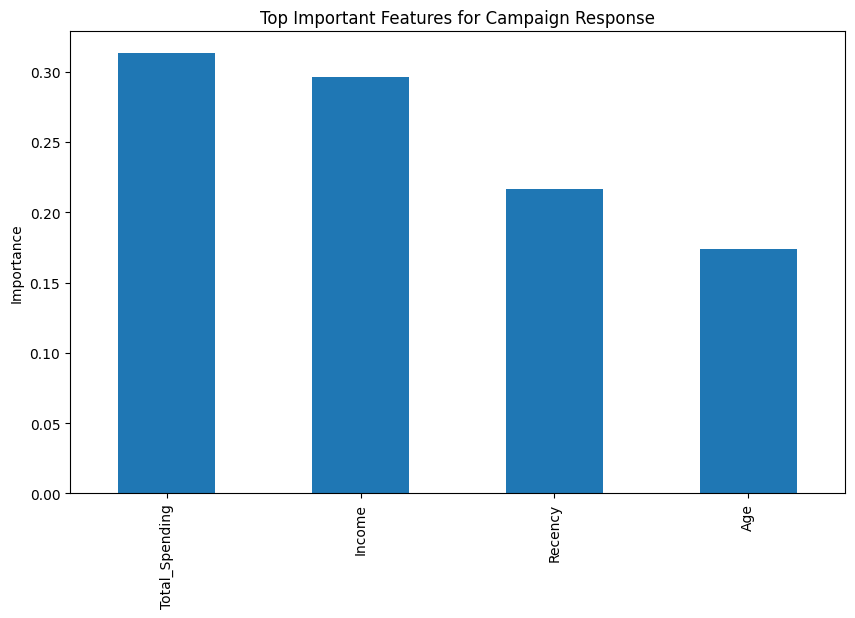

In [41]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind="bar")

plt.title("Top Important Features for Campaign Response")

plt.ylabel("Importance")

plt.show()

In [42]:
df.groupby("Cluster")[["Income","Total_Spending","Age","Recency"]].mean()

,Income,Total_Spending,Age,Recency
Cluster,,,,
0,74114.803665,1344.900524,48.138743,38.505236
1,39266.698427,198.629371,54.756993,77.583916
2,71958.119891,1268.335150,65.929155,70.501362
3,53193.017943,472.169856,67.382775,25.832536
4,32098.399594,124.699797,47.430020,28.107505


In [43]:
df["Cluster"].value_counts()

Cluster
1    572
4    493
3    418
0    382
2    367
Name: count, dtype: int64

In [44]:
import pickle

pickle.dump(model, open("campaign_response_model.pkl","wb"))

The model was trained using customer income, recency, age, and total spending to predict whether a customer will respond to a marketing campaign. The trained model was then deployed using Streamlit to create a simple web interface for predictions.

## Conclusion

In this analysis, we explored customer demographic and purchasing data to gain insights into customer behavior. Data preprocessing steps such as handling missing values, feature engineering, and outlier detection were performed to prepare the dataset for analysis.

Unsupervised learning techniques including K-Means and Hierarchical Clustering were applied to segment customers into distinct groups based on income, spending behavior, and recency. PCA was used to visualize the clusters effectively in a lower-dimensional space.

Finally, a machine learning model was trained to predict customer campaign responses, helping identify factors that influence marketing success. The results demonstrate how data-driven approaches can assist businesses in understanding customer patterns, improving targeting strategies, and optimizing marketing campaigns.